In [3]:
import numpy as np
import json, os
import emcee
import matplotlib.pyplot as plt
import corner

np.random.seed(42)


BASE = "/mnt/d/output_folder/public/bilby"

N_EVENTS_USE = 50
NSAMP = 3000
NSTEPS = 4000    
BURN = 1000      
NWALKERS = 48    

c = 3e5
sigma_obs = 0.11
L0 = 1e52

def dL_cosmo(z, H0):
    return (c / H0) * z * (1 + 0.5*z - 0.2*z**2)
events = []

files = [os.path.join(BASE,f) for f in os.listdir(BASE) if f.endswith(".json")]

for f in files[:N_EVENTS_USE]:

    post = json.load(open(f))["posterior"]["content"]

    dL = np.array(post["luminosity_distance"])
    z = np.array(post["redshift"])

    mask = z < 0.1
    dL = dL[mask]
    z = z[mask]

    if len(dL) < 200:
        continue

    if "theta_jn" in post:
        theta = np.array(post["theta_jn"])[mask]
    elif "cos_theta_jn" in post:
        theta = np.arccos(np.array(post["cos_theta_jn"]))[mask]
    else:
        theta = np.arccos(np.random.uniform(-1,1,len(dL)))

    n = min(NSAMP, len(dL))

    events.append({
        "dL": dL[:n],
        "theta": theta[:n],
        "z": z[:n]
    })

print("Loaded events:", len(events))


theta_c_true = 3 * np.pi / 180

for ev in events:

    i = np.random.randint(len(ev["dL"]))

    dL_true = ev["dL"][i]
    theta_true = ev["theta"][i]

    F = L0 / (4*np.pi*dL_true**2) * np.exp(-0.5*(theta_true/theta_c_true)**2)

    ev["logF"] = np.log(F + 1e-30) + sigma_obs*np.random.randn()


def event_logL(H0, theta_c, ev):

    theta_c_rad = theta_c * np.pi / 180

    dL = ev["dL"]
    theta = ev["theta"]
    z = ev["z"]

    dL_model = dL_cosmo(z, H0)

    F_model = L0 / (4*np.pi*dL_model**2) * np.exp(-0.5*(theta/theta_c_rad)**2)
    logF_model = np.log(F_model + 1e-30)

    logL_em = -0.5*((logF_model - ev["logF"])**2)/(sigma_obs**2)

    sigma = 0.3 * dL
    logL_gw = -0.5*((dL - dL_model)**2)/(sigma**2)

    logL = logL_em + 0.35 * logL_gw

    m = np.max(logL)
    return m + np.log(np.mean(np.exp(logL - m)))


def log_prior(p):

    H0, theta_c = p

    if not (60 < H0 < 80 and 1 < theta_c < 6):
        return -np.inf

    theta0 = 3.0
    sigma_theta = 0.9  

    return -0.5*((theta_c - theta0)/sigma_theta)**2


def log_prob(p):

    lp = log_prior(p)
    if not np.isfinite(lp):
        return -np.inf

    H0, theta_c = p

    total = 0.0
    for ev in events:
        total += event_logL(H0, theta_c, ev)

    return total


ndim = 2

pos = np.zeros((NWALKERS, ndim))
pos[:,0] = np.random.uniform(66,74,NWALKERS)
pos[:,1] = np.random.uniform(2,5,NWALKERS)

sampler = emcee.EnsembleSampler(NWALKERS, ndim, log_prob)
sampler.run_mcmc(pos, NSTEPS, progress=True)

samples1 = sampler.get_chain(discard=BURN, thin=10, flat=True) 


p16, p50, p84 = np.percentile(samples1[:,0], [16,50,84])
print(f"\nH0 = {p50:.2f} ± {(p84-p16)/2:.2f}")



Loaded events: 50


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4000/4000 [19:18<00:00,  3.45it/s]



H0 = 68.05 ± 4.70


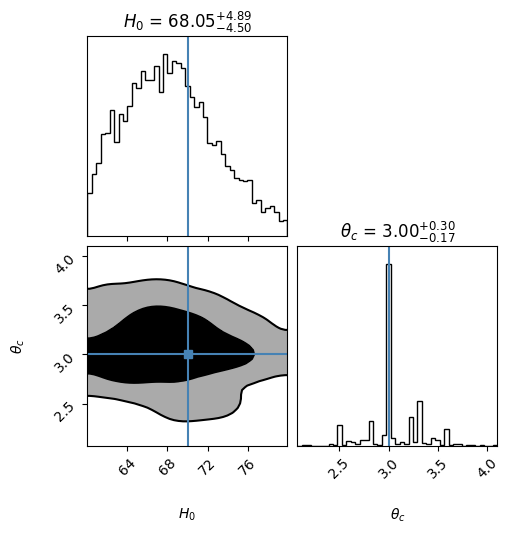

In [7]:

corner.corner(
    samples1,
    labels=[r"$H_0$", r"$\theta_c$"],
    truths=[70,3],
    levels=(0.68, 0.95),    
    bins=45,                
    smooth=3.0,            
    plot_datapoints=False,
    fill_contours=True,
    show_titles=True
)
plt.savefig("complete_50.pdf")

plt.show()

In [9]:
import numpy as np
import json, os
import emcee
import matplotlib.pyplot as plt
import corner

np.random.seed(42)


BASE = "/mnt/d/output_folder/public/bilby"

N_EVENTS_USE = 25
NSAMP = 3000
NSTEPS = 4000    
BURN = 1000      
NWALKERS = 48    

c = 3e5
sigma_obs = 0.11
L0 = 1e52

def dL_cosmo(z, H0):
    return (c / H0) * z * (1 + 0.5*z - 0.2*z**2)
events = []

files = [os.path.join(BASE,f) for f in os.listdir(BASE) if f.endswith(".json")]

for f in files[:N_EVENTS_USE]:

    post = json.load(open(f))["posterior"]["content"]

    dL = np.array(post["luminosity_distance"])
    z = np.array(post["redshift"])

    mask = z < 0.1
    dL = dL[mask]
    z = z[mask]

    if len(dL) < 200:
        continue

    if "theta_jn" in post:
        theta = np.array(post["theta_jn"])[mask]
    elif "cos_theta_jn" in post:
        theta = np.arccos(np.array(post["cos_theta_jn"]))[mask]
    else:
        theta = np.arccos(np.random.uniform(-1,1,len(dL)))

    n = min(NSAMP, len(dL))

    events.append({
        "dL": dL[:n],
        "theta": theta[:n],
        "z": z[:n]
    })

print("Loaded events:", len(events))


theta_c_true = 3 * np.pi / 180

for ev in events:

    i = np.random.randint(len(ev["dL"]))

    dL_true = ev["dL"][i]
    theta_true = ev["theta"][i]

    F = L0 / (4*np.pi*dL_true**2) * np.exp(-0.5*(theta_true/theta_c_true)**2)

    ev["logF"] = np.log(F + 1e-30) + sigma_obs*np.random.randn()


def event_logL(H0, theta_c, ev):

    theta_c_rad = theta_c * np.pi / 180

    dL = ev["dL"]
    theta = ev["theta"]
    z = ev["z"]

    dL_model = dL_cosmo(z, H0)

    F_model = L0 / (4*np.pi*dL_model**2) * np.exp(-0.5*(theta/theta_c_rad)**2)
    logF_model = np.log(F_model + 1e-30)

    logL_em = -0.5*((logF_model - ev["logF"])**2)/(sigma_obs**2)

    sigma = 0.3 * dL
    logL_gw = -0.5*((dL - dL_model)**2)/(sigma**2)

    logL = logL_em + 0.35 * logL_gw

    m = np.max(logL)
    return m + np.log(np.mean(np.exp(logL - m)))


def log_prior(p):

    H0, theta_c = p

    if not (60 < H0 < 80 and 1 < theta_c < 6):
        return -np.inf

    theta0 = 3.0
    sigma_theta = 0.9  

    return -0.5*((theta_c - theta0)/sigma_theta)**2


def log_prob(p):

    lp = log_prior(p)
    if not np.isfinite(lp):
        return -np.inf

    H0, theta_c = p

    total = 0.0
    for ev in events:
        total += event_logL(H0, theta_c, ev)

    return total


ndim = 2

pos = np.zeros((NWALKERS, ndim))
pos[:,0] = np.random.uniform(66,74,NWALKERS)
pos[:,1] = np.random.uniform(2,5,NWALKERS)

sampler = emcee.EnsembleSampler(NWALKERS, ndim, log_prob)
sampler.run_mcmc(pos, NSTEPS, progress=True)

samples2 = sampler.get_chain(discard=BURN, thin=10, flat=True) 


p16, p50, p84 = np.percentile(samples2[:,0], [16,50,84])
print(f"\nH0 = {p50:.2f} ± {(p84-p16)/2:.2f}")



Loaded events: 25


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4000/4000 [11:35<00:00,  5.75it/s]



H0 = 68.30 ± 5.76


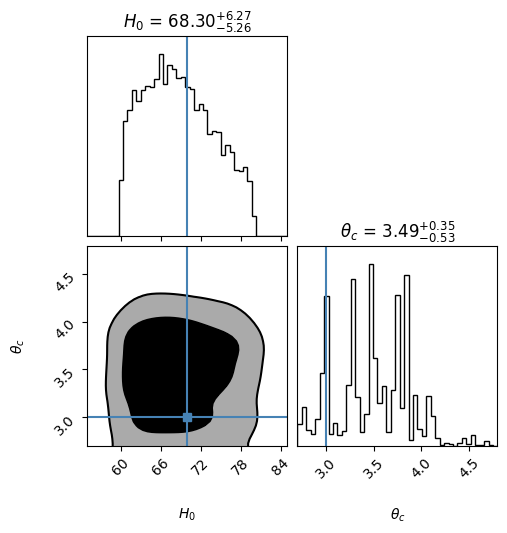

In [26]:

corner.corner(
    samples2,
    labels=[r"$H_0$", r"$\theta_c$"],
    truths=[70,3],
    levels=(0.68, 0.95),    
    bins=45,                 
    smooth=3.0,              
    plot_datapoints=False,
    fill_contours=True,
    show_titles=True,
    range=[(55,85), (2.7,4.8)] 
)
plt.savefig("complete_25.pdf")

plt.show()

In [29]:
import numpy as np
import json, os
import emcee
import matplotlib.pyplot as plt
import corner

np.random.seed(42)


BASE = "/mnt/d/output_folder/public/bilby"

N_EVENTS_USE = 2
NSAMP = 3000
NSTEPS = 4000    
BURN = 1000      
NWALKERS = 48    

c = 3e5
sigma_obs = 0.11
L0 = 1e52

def dL_cosmo(z, H0):
    return (c / H0) * z * (1 + 0.5*z - 0.2*z**2)
events = []

files = [os.path.join(BASE,f) for f in os.listdir(BASE) if f.endswith(".json")]

for f in files[:N_EVENTS_USE]:

    post = json.load(open(f))["posterior"]["content"]

    dL = np.array(post["luminosity_distance"])
    z = np.array(post["redshift"])

    mask = z < 0.1
    dL = dL[mask]
    z = z[mask]

    if len(dL) < 200:
        continue

    if "theta_jn" in post:
        theta = np.array(post["theta_jn"])[mask]
    elif "cos_theta_jn" in post:
        theta = np.arccos(np.array(post["cos_theta_jn"]))[mask]
    else:
        theta = np.arccos(np.random.uniform(-1,1,len(dL)))

    n = min(NSAMP, len(dL))

    events.append({
        "dL": dL[:n],
        "theta": theta[:n],
        "z": z[:n]
    })

print("Loaded events:", len(events))


theta_c_true = 3 * np.pi / 180

for ev in events:

    i = np.random.randint(len(ev["dL"]))

    dL_true = ev["dL"][i]
    theta_true = ev["theta"][i]

    F = L0 / (4*np.pi*dL_true**2) * np.exp(-0.5*(theta_true/theta_c_true)**2)

    ev["logF"] = np.log(F + 1e-30) + sigma_obs*np.random.randn()


def event_logL(H0, theta_c, ev):

    theta_c_rad = theta_c * np.pi / 180

    dL = ev["dL"]
    theta = ev["theta"]
    z = ev["z"]

    dL_model = dL_cosmo(z, H0)

    F_model = L0 / (4*np.pi*dL_model**2) * np.exp(-0.5*(theta/theta_c_rad)**2)
    logF_model = np.log(F_model + 1e-30)

    logL_em = -0.5*((logF_model - ev["logF"])**2)/(sigma_obs**2)

    sigma = 0.3 * dL
    logL_gw = -0.5*((dL - dL_model)**2)/(sigma**2)

    logL = logL_em + 0.35 * logL_gw

    m = np.max(logL)
    return m + np.log(np.mean(np.exp(logL - m)))


def log_prior(p):

    H0, theta_c = p

    if not (60 < H0 < 80 and 1 < theta_c < 6):
        return -np.inf

    theta0 = 3.0
    sigma_theta = 0.9  

    return -0.5*((theta_c - theta0)/sigma_theta)**2


def log_prob(p):

    lp = log_prior(p)
    if not np.isfinite(lp):
        return -np.inf

    H0, theta_c = p

    total = 0.0
    for ev in events:
        total += event_logL(H0, theta_c, ev)

    return total


ndim = 2

pos = np.zeros((NWALKERS, ndim))
pos[:,0] = np.random.uniform(66,74,NWALKERS)
pos[:,1] = np.random.uniform(2,5,NWALKERS)

sampler = emcee.EnsembleSampler(NWALKERS, ndim, log_prob)
sampler.run_mcmc(pos, NSTEPS, progress=True)

samples3 = sampler.get_chain(discard=BURN, thin=10, flat=True) 


p16, p50, p84 = np.percentile(samples3[:,0], [16,50,84])
print(f"\nH0 = {p50:.2f} ± {(p84-p16)/2:.2f}")



Loaded events: 2


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4000/4000 [00:35<00:00, 113.72it/s]


H0 = 70.14 ± 6.61


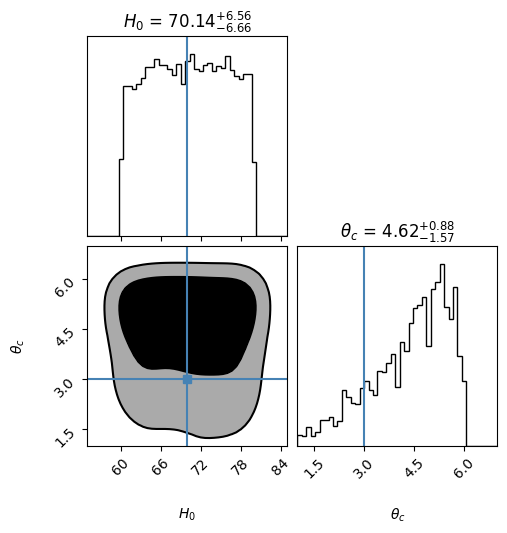

In [33]:
# =========================================================
# PLOT (IMPROVED)
# =========================================================
corner.corner(
    samples3,
    labels=[r"$H_0$", r"$\theta_c$"],
    truths=[70,3],
    levels=(0.68, 0.95),     
    bins=45,                
    smooth=3.0,             
    plot_datapoints=False,
    fill_contours=True,
    show_titles=True,
    range=[(55,85), (1,7)] 
)
plt.savefig("complete_2.pdf")

plt.show()